# Seller and Delivery Performance Analysis

## Business Question

Which sellers, regions, and delivery patterns create the strongest or weakest customer outcomes, and where should the business focus operational improvement?

## Objectives

- Measure seller revenue and order volume
- Compare seller customer satisfaction
- Evaluate seller delivery speed and late-delivery rates
- Identify high-value sellers with operational risk
- Compare seller performance across states
- Recommend actions for seller management and logistics improvement

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

if (Path.cwd() / "data" / "raw").exists():
    DATA_PATH = Path.cwd() / "data" / "raw"
elif (Path.cwd().parent / "data" / "raw").exists():
    DATA_PATH = Path.cwd().parent / "data" / "raw"
else:
    raise FileNotFoundError("Could not find the data/raw folder.")

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH / "olist_geolocation_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [2]:
print(f"Orders: {orders.shape}")
print(f"Order items: {order_items.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Sellers: {sellers.shape}")

Orders: (99441, 8)
Order items: (112650, 7)
Reviews: (99224, 7)
Sellers: (3095, 4)


### Dataset Scope

The analysis combines order-level delivery information, item-level seller and revenue data, customer review scores, and seller location data.

Because a single order may contain items from multiple sellers, the analysis first creates one record per seller per order before calculating seller-level metrics.

In [3]:
seller_orders = (
    order_items
    .groupby(["seller_id", "order_id"])
    .agg(
        units_sold=("order_item_id", "count"),
        revenue=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

seller_orders.head()

,seller_id,order_id,units_sold,revenue,freight_value
0,0015a82c2db000af6aaaf3ae2ecb0532,7f39ba4c9052be115350065d07583cac,1,895.0,21.02
1,0015a82c2db000af6aaaf3ae2ecb0532,9dc8d1a6f16f1b89874c29c9d8d30447,1,895.0,21.02
2,0015a82c2db000af6aaaf3ae2ecb0532,d455a8cb295653b55abda06d434ab492,1,895.0,21.02
3,001cca7ae9ae17fb1caed9dfb1094831,006e43460a55bc60c0a437521e426529,1,99.0,43.06
4,001cca7ae9ae17fb1caed9dfb1094831,00dfb074b5c910fbd08e04691c4b712f,1,99.5,35.07


In [4]:
print(f"Original order-item rows: {len(order_items):,}")
print(f"Seller-order rows: {len(seller_orders):,}")

Original order-item rows: 112,650
Seller-order rows: 100,010


In [5]:
order_reviews = (
    reviews
    .groupby("order_id")
    .agg(
        review_score=("review_score", "mean")
    )
    .reset_index()
)

order_reviews.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [6]:
seller_analysis = (
    seller_orders
    .merge(orders, on="order_id", how="left")
    .merge(order_reviews, on="order_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)

seller_analysis.head()

,seller_id,order_id,units_sold,revenue,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,seller_zip_code_prefix,seller_city,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,7f39ba4c9052be115350065d07583cac,1,895.0,21.02,d7fc82cbeafea77bd0a8fbbf6296e387,delivered,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09 00:00:00,1.0,9080,santo andre,SP
1,0015a82c2db000af6aaaf3ae2ecb0532,9dc8d1a6f16f1b89874c29c9d8d30447,1,895.0,21.02,d9442164acf4b03109425633efaa0cfc,delivered,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06 00:00:00,5.0,9080,santo andre,SP
2,0015a82c2db000af6aaaf3ae2ecb0532,d455a8cb295653b55abda06d434ab492,1,895.0,21.02,944b72539d7e1f7f7fc6e46639ef1fe3,delivered,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30 00:00:00,5.0,9080,santo andre,SP
3,001cca7ae9ae17fb1caed9dfb1094831,006e43460a55bc60c0a437521e426529,1,99.0,43.06,23bfd4316e261786deed5a08231c75bc,delivered,2017-05-11 00:24:35,2017-05-11 01:30:22,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02 00:00:00,5.0,29156,cariacica,ES
4,001cca7ae9ae17fb1caed9dfb1094831,00dfb074b5c910fbd08e04691c4b712f,1,99.5,35.07,a5ced4926d7d8fa71e9be2b007720356,delivered,2017-06-08 19:43:35,2017-06-08 19:55:19,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10 00:00:00,5.0,29156,cariacica,ES


In [7]:
seller_analysis.shape

(100010, 16)

In [8]:
seller_analysis[
    [
        "seller_id",
        "order_status",
        "review_score",
        "seller_state"
    ]
].isnull().sum()

seller_id         0
order_status      0
review_score    763
seller_state      0
dtype: int64

In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    seller_analysis[column] = pd.to_datetime(
        seller_analysis[column],
        errors="coerce"
    )

seller_analysis["delivery_days"] = (
    seller_analysis["order_delivered_customer_date"]
    - seller_analysis["order_purchase_timestamp"]
).dt.days

seller_analysis["late_delivery"] = np.where(
    seller_analysis["order_delivered_customer_date"].isna(),
    np.nan,
    (
        seller_analysis["order_delivered_customer_date"]
        > seller_analysis["order_estimated_delivery_date"]
    ).astype(float)
)

In [10]:
seller_analysis["delivery_days"] = (
    seller_analysis["order_delivered_customer_date"]
    - seller_analysis["order_purchase_timestamp"]
).dt.days

seller_analysis["late_delivery"] = np.where(
    seller_analysis["order_delivered_customer_date"].isna(),
    np.nan,
    (
        seller_analysis["order_delivered_customer_date"]
        > seller_analysis["order_estimated_delivery_date"]
    ).astype(float)
)

In [11]:
seller_analysis[
    [
        "order_id",
        "seller_id",
        "delivery_days",
        "late_delivery",
        "review_score"
    ]
].head()

,order_id,seller_id,delivery_days,late_delivery,review_score
0,7f39ba4c9052be115350065d07583cac,0015a82c2db000af6aaaf3ae2ecb0532,9.0,0.0,1.0
1,9dc8d1a6f16f1b89874c29c9d8d30447,0015a82c2db000af6aaaf3ae2ecb0532,12.0,0.0,5.0
2,d455a8cb295653b55abda06d434ab492,0015a82c2db000af6aaaf3ae2ecb0532,10.0,0.0,5.0
3,006e43460a55bc60c0a437521e426529,001cca7ae9ae17fb1caed9dfb1094831,8.0,0.0,5.0
4,00dfb074b5c910fbd08e04691c4b712f,001cca7ae9ae17fb1caed9dfb1094831,6.0,0.0,5.0


In [12]:
seller_summary = (
    seller_analysis
    .groupby("seller_id")
    .agg(
        seller_state=("seller_state", "first"),
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        total_freight=("freight_value", "sum"),
        avg_review_score=("review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("late_delivery", "mean")
    )
    .reset_index()
)

seller_summary["revenue_per_order"] = (
    seller_summary["revenue"] / seller_summary["orders"]
)

seller_summary["freight_per_order"] = (
    seller_summary["total_freight"] / seller_summary["orders"]
)

seller_summary.head()

,seller_id,seller_state,orders,units_sold,revenue,total_freight,avg_review_score,avg_delivery_days,late_delivery_rate,revenue_per_order,freight_per_order
0,0015a82c2db000af6aaaf3ae2ecb0532,SP,3,3,2685.00,63.06,3.666667,10.333333,0.000000,895.000000,21.020000
1,001cca7ae9ae17fb1caed9dfb1094831,ES,200,239,25080.03,8854.14,3.984772,12.938462,0.066667,125.400150,44.270700
2,001e6ad469a905060d959994f1b41e4f,RJ,1,1,250.00,17.94,1.000000,NaN,NaN,250.000000,17.940000
3,002100f778ceb8431b7a1020ff7ab48f,SP,51,55,1234.50,793.66,3.901961,15.960000,0.180000,24.205882,15.561961
4,003554e2dce176b5555353e4f3555ac8,GO,1,1,120.00,19.38,5.000000,4.000000,0.000000,120.000000,19.380000


In [13]:
seller_summary["late_delivery_pct"] = (
    seller_summary["late_delivery_rate"] * 100
)

seller_summary[
    [
        "avg_review_score",
        "avg_delivery_days",
        "late_delivery_pct",
        "revenue_per_order",
        "freight_per_order"
    ]
] = seller_summary[
    [
        "avg_review_score",
        "avg_delivery_days",
        "late_delivery_pct",
        "revenue_per_order",
        "freight_per_order"
    ]
].round(2)

In [14]:
top_revenue_sellers = (
    seller_summary
    .sort_values("revenue", ascending=False)
    .head(15)
)

top_revenue_sellers

,seller_id,seller_state,orders,units_sold,revenue,total_freight,avg_review_score,avg_delivery_days,late_delivery_rate,revenue_per_order,freight_per_order,late_delivery_pct
857,4869f7a5dfa277a7dca6462dcf3b52b2,SP,1132,1156,229472.63,20168.07,4.13,14.61,0.115658,202.71,17.82,11.57
1013,53243585a1d6dc2643021fd1853d8905,BA,358,410,222776.05,13080.63,4.13,12.98,0.043103,622.28,36.54,4.31
881,4a3ca9315b744ce9f8e9374361493884,SP,1806,1987,200472.92,35067.04,3.83,14.01,0.110045,111.00,19.42,11.00
3024,fa1c13f2614d7b5c4749cbc52fecda94,SP,585,586,194042.03,10042.70,4.34,12.85,0.102076,331.70,17.17,10.21
1535,7c67e1448b00f6e969d365cea6b010ab,SP,982,1364,187923.89,51612.55,3.49,21.87,0.100719,191.37,52.56,10.07
1560,7e93a43ef30c4f03f38b393420bc753a,SP,336,340,176431.87,6322.18,4.21,10.81,0.056426,525.09,18.82,5.64
2643,da8622b14eb17ae2831f4ac5b9dab84a,SP,1314,1551,160236.57,24955.75,4.17,10.72,0.076278,121.95,18.99,7.63
1505,7a67c85e85bb2ce8582c35f2203ad736,SP,1160,1171,141745.53,20902.85,4.24,10.72,0.059389,122.19,18.02,5.94
192,1025f0e2d44d7041d6cf58b6550e0bfa,SP,915,1428,138968.55,33892.14,3.99,11.92,0.101099,151.88,37.04,10.11
1824,955fee9216a65b617aa5c0531780ce60,SP,1287,1499,135171.70,25430.98,4.16,10.33,0.077716,105.03,19.76,7.77


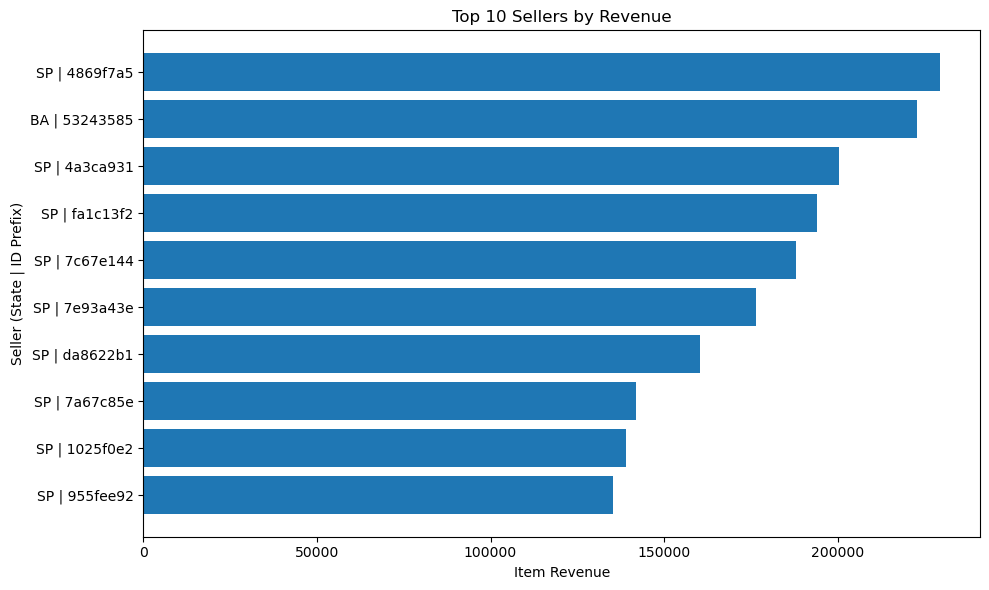

In [15]:
top_10_revenue_sellers = (
    top_revenue_sellers
    .head(10)
    .sort_values("revenue")
    .copy()
)

top_10_revenue_sellers["seller_label"] = (
    top_10_revenue_sellers["seller_state"]
    + " | "
    + top_10_revenue_sellers["seller_id"].str[:8]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_revenue_sellers["seller_label"],
    top_10_revenue_sellers["revenue"]
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Item Revenue")
plt.ylabel("Seller (State | ID Prefix)")
plt.tight_layout()
plt.show()

### Finding 1 — Seller Revenue Performance

Revenue is concentrated among a relatively small group of sellers.

The highest-revenue sellers represent strategically important marketplace partners because disruption, quality issues, or delivery problems among these sellers could affect a meaningful share of total platform revenue.

Seller performance should therefore be evaluated using both commercial contribution and customer experience.

In [16]:
established_sellers = seller_summary[
    seller_summary["orders"] >= 50
].copy()

best_rated_sellers = (
    established_sellers
    .sort_values(
        ["avg_review_score", "orders"],
        ascending=[False, False]
    )
    .head(15)
)

best_rated_sellers

,seller_id,seller_state,orders,units_sold,revenue,total_freight,avg_review_score,avg_delivery_days,late_delivery_rate,revenue_per_order,freight_per_order,late_delivery_pct
2531,d13e50eaa47b4cbe9eb81465865d8cfc,SP,67,69,7155.05,857.79,4.82,4.64,0.212121,106.79,12.80,21.21
2629,d9bd94811c3338dceb4181f3dbc0c73e,SP,54,61,6911.02,771.09,4.80,7.54,0.111111,127.98,14.28,11.11
2580,d566c37fa119d5e66c4e9052e83ee4ea,SP,65,73,5145.70,979.22,4.69,5.34,0.030769,79.16,15.06,3.08
647,376a891762bbdecbc02b4b6adec3fdda,GO,57,58,6406.23,1287.40,4.67,11.81,0.035088,112.39,22.59,3.51
322,1bb2bdb95f4841f1bba2c0d2cd83d3c9,SP,81,85,5002.71,1146.56,4.64,11.99,0.075949,61.76,14.16,7.59
201,116ccb1a1604bc88e4d234a8c23f33de,SP,61,73,2004.89,943.44,4.64,8.59,0.065574,32.87,15.47,6.56
100,080199a181c46c657dc5aa235411be3b,SP,79,83,14504.20,1040.68,4.62,7.61,0.025316,183.60,13.17,2.53
2077,ac3508719a1d8f5b7614b798f70af136,RS,103,104,12775.84,3016.39,4.60,8.93,0.029703,124.04,29.29,2.97
1123,5b925e1d006e9476d738aa200751b73b,SP,63,63,7748.50,1053.34,4.60,10.46,0.063492,122.99,16.72,6.35
2802,e882b2a25a10b9c057cc49695f222c19,RJ,57,58,51057.54,2856.22,4.58,9.11,0.000000,895.75,50.11,0.00


### Finding 2 — High-Quality Seller Partners

The highest-rated established sellers combine meaningful order volume with consistently positive customer feedback.

These sellers represent potential benchmark partners. Their fulfilment, communication, product quality, and customer service practices may provide lessons that can be shared with lower-performing sellers.

In [17]:
average_established_rating = (
    established_sellers["avg_review_score"].mean()
)

high_revenue_low_rating_sellers = (
    established_sellers[
        established_sellers["avg_review_score"]
        < average_established_rating
    ]
    .sort_values("revenue", ascending=False)
    .head(15)
)

high_revenue_low_rating_sellers

,seller_id,seller_state,orders,units_sold,revenue,total_freight,avg_review_score,avg_delivery_days,late_delivery_rate,revenue_per_order,freight_per_order,late_delivery_pct
881,4a3ca9315b744ce9f8e9374361493884,SP,1806,1987,200472.92,35067.04,3.83,14.01,0.110045,111.00,19.42,11.00
1535,7c67e1448b00f6e969d365cea6b010ab,SP,982,1364,187923.89,51612.55,3.49,21.87,0.100719,191.37,52.56,10.07
192,1025f0e2d44d7041d6cf58b6550e0bfa,SP,915,1428,138968.55,33892.14,3.99,11.92,0.101099,151.88,37.04,10.11
1235,6560211a19b47992c3666cc44a7e94c0,SP,1854,2033,123304.83,27960.94,3.94,9.15,0.064321,66.51,15.08,6.43
1540,7d13fca15225358621be4086e1eb0964,SP,565,578,113628.97,8632.05,4.02,15.27,0.121864,201.11,15.28,12.19
1153,5dceca129747e92ff8ef7a997dc4f8ca,SP,325,346,112155.53,13661.39,3.98,11.07,0.062112,345.09,42.04,6.21
2481,cc419e0650a3c5ba77189a1882b7556a,SP,1706,1775,104288.42,25668.99,4.07,11.11,0.061175,61.13,15.05,6.12
2485,cca3071e3e9bb7d12640c9fbe2301306,SP,712,830,64009.89,14371.40,3.84,13.66,0.058655,89.90,20.18,5.87
47,04308b1ee57b6625f47df1d56f00eedf,SC,94,94,60130.60,3054.39,3.88,18.42,0.119565,639.69,32.49,11.96
989,522620dcb18a6b31cd7bdf73665113a9,PR,174,180,57168.49,4661.32,3.89,14.89,0.104651,328.55,26.79,10.47


### Finding 3 — Revenue at Risk

Several commercially important sellers perform below the established-seller average review score.

These sellers should receive priority attention because customer experience problems could affect both retention and meaningful marketplace revenue.

The business should determine whether the underlying causes relate to product quality, inaccurate listings, seller communication, fulfilment, or delivery performance.

In [18]:
highest_late_delivery_sellers = (
    established_sellers
    .sort_values(
        ["late_delivery_pct", "orders"],
        ascending=[False, False]
    )
    .head(15)
)

highest_late_delivery_sellers[
    [
        "seller_id",
        "seller_state",
        "orders",
        "revenue",
        "avg_review_score",
        "avg_delivery_days",
        "late_delivery_pct"
    ]
]

,seller_id,seller_state,orders,revenue,avg_review_score,avg_delivery_days,late_delivery_pct
1032,54965bbe3e4f07ae045b90b0b8541f52,PR,78,10961.30,3.00,25.66,30.14
492,2a1348e9addc1af5aaa619b1a3679d6b,MG,52,2843.00,3.12,26.88,27.08
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,SP,98,8816.70,3.01,16.51,26.04
2298,beadbee30901a7f61d031b6b686095ad,SP,64,4373.98,3.91,13.61,25.00
81,06a2c3af7b3aee5d69171b0e14f0ee87,MA,392,36408.95,3.99,17.26,23.14
2458,cac4c8e7b1ca6252d8f20b2fc1a2e4af,SP,75,4168.18,3.55,17.76,22.97
333,1ca7077d890b907f89be8c954a02686a,SP,115,13341.57,2.33,15.01,22.22
1180,6039e27294dc75811c0d8a39069f52c0,SP,64,13670.70,3.69,17.46,22.22
1387,712e6ed8aa4aa1fa65dab41fed5737e4,SC,79,39815.00,3.38,24.27,22.08
2831,ea566164622c6b439516ab18062c42cd,SP,50,10309.42,3.78,13.62,22.00


### Finding 4 — Seller Delivery Risk

Some established sellers show materially higher late-delivery rates than their peers.

These sellers should be reviewed for inventory availability, dispatch speed, carrier handoff, order-processing practices, and geographic delivery constraints.

Late delivery should also be compared with review scores to assess whether logistics problems are translating into measurable customer dissatisfaction.

In [19]:
delivery_rating_relationship = (
    established_sellers[
        [
            "late_delivery_pct",
            "avg_delivery_days",
            "avg_review_score"
        ]
    ]
    .corr()
)

delivery_rating_relationship

,late_delivery_pct,avg_delivery_days,avg_review_score
late_delivery_pct,1.000000,0.537556,-0.519675
avg_delivery_days,0.537556,1.000000,-0.570343
avg_review_score,-0.519675,-0.570343,1.000000


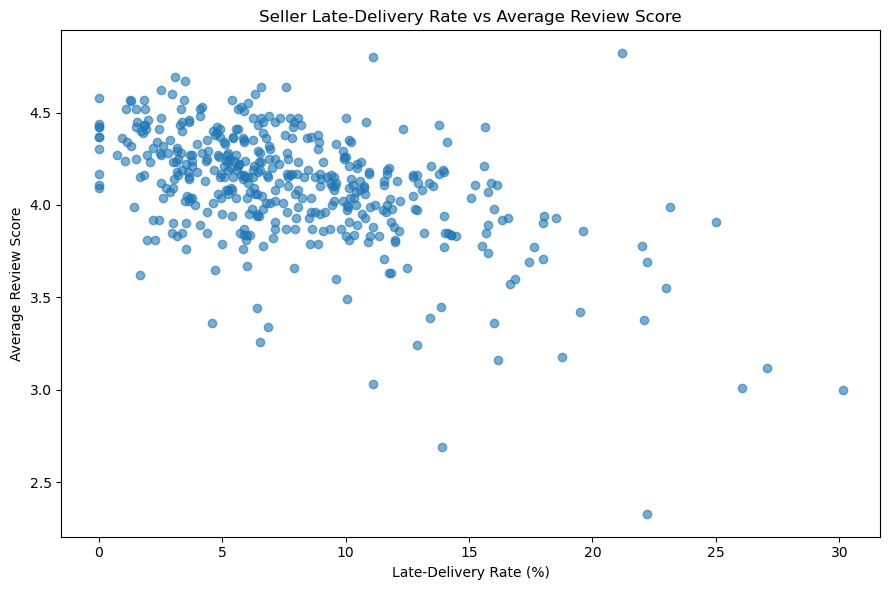

In [20]:
plt.figure(figsize=(9, 6))

plt.scatter(
    established_sellers["late_delivery_pct"],
    established_sellers["avg_review_score"],
    alpha=0.6
)

plt.title("Seller Late-Delivery Rate vs Average Review Score")
plt.xlabel("Late-Delivery Rate (%)")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.show()

### Finding 5 — Delivery and Customer Satisfaction

The comparison indicates whether sellers with higher late-delivery rates also tend to receive lower customer ratings.

This relationship should be interpreted as association rather than causation. Customer reviews may also be influenced by product quality, seller communication, order accuracy, and customer expectations.

In [21]:
print(seller_analysis["late_delivery"].dtype)
print(seller_analysis["late_delivery"].value_counts(dropna=False))

float64
late_delivery
0.0    89972
1.0     7845
NaN     2193
Name: count, dtype: int64


In [22]:
seller_state_summary = (
    seller_analysis
    .dropna(subset=["seller_state"])
    .groupby("seller_state")
    .agg(
        sellers=("seller_id", "nunique"),
        orders=("order_id", "nunique"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("late_delivery", "mean")
    )
    .reset_index()
)

seller_state_summary["late_delivery_pct"] = (
    seller_state_summary["late_delivery_rate"] * 100
).round(2)

seller_state_summary["revenue"] = (
    seller_state_summary["revenue"].round(2)
)

seller_state_summary["avg_review_score"] = (
    seller_state_summary["avg_review_score"].round(2)
)

seller_state_summary["avg_delivery_days"] = (
    seller_state_summary["avg_delivery_days"].round(2)
)

seller_state_summary = seller_state_summary.sort_values(
    "revenue",
    ascending=False
)

seller_state_summary

,seller_state,sellers,orders,units_sold,revenue,avg_review_score,avg_delivery_days,late_delivery_rate,late_delivery_pct
22,SP,1849,70188,80342,8753396.21,4.06,11.85,0.086704,8.67
15,PR,349,7673,8671,1261887.21,4.12,12.92,0.064187,6.42
8,MG,244,7930,8827,1011564.74,4.17,12.36,0.055771,5.58
16,RJ,171,4353,4818,843984.22,4.15,11.59,0.083885,8.39
20,SC,190,3667,4075,632426.07,4.13,13.21,0.059590,5.96
19,RS,129,1989,2199,378559.54,4.29,11.04,0.042770,4.28
2,BA,19,569,643,285561.56,4.11,13.44,0.058182,5.82
4,DF,30,824,899,97749.48,4.06,12.02,0.060644,6.06
13,PE,9,406,448,91493.85,4.25,12.40,0.044665,4.47
6,GO,40,463,520,66399.21,4.31,12.39,0.039911,3.99


In [23]:
established_seller_states = (
    seller_state_summary[
        seller_state_summary["orders"] >= 100
    ]
    .copy()
)

established_seller_states[
    [
        "seller_state",
        "sellers",
        "orders",
        "units_sold",
        "revenue",
        "avg_review_score",
        "avg_delivery_days",
        "late_delivery_pct"
    ]
].sort_values("revenue", ascending=False)

,seller_state,sellers,orders,units_sold,revenue,avg_review_score,avg_delivery_days,late_delivery_pct
22,SP,1849,70188,80342,8753396.21,4.06,11.85,8.67
15,PR,349,7673,8671,1261887.21,4.12,12.92,6.42
8,MG,244,7930,8827,1011564.74,4.17,12.36,5.58
16,RJ,171,4353,4818,843984.22,4.15,11.59,8.39
20,SC,190,3667,4075,632426.07,4.13,13.21,5.96
19,RS,129,1989,2199,378559.54,4.29,11.04,4.28
2,BA,19,569,643,285561.56,4.11,13.44,5.82
4,DF,30,824,899,97749.48,4.06,12.02,6.06
13,PE,9,406,448,91493.85,4.25,12.40,4.47
6,GO,40,463,520,66399.21,4.31,12.39,3.99


### Finding 6 — Regional Seller Performance

Seller activity is heavily concentrated in São Paulo, which accounts for 1,849 sellers, more than 70,000 orders, and approximately 8.75 million in item revenue.

Paraná and Minas Gerais form the next largest seller markets but remain substantially smaller than São Paulo. This creates operational efficiency through marketplace concentration, but it also introduces geographic dependency.

Among states with meaningful order volume, customer satisfaction remains generally strong. Rio Grande do Sul records one of the highest average review scores, while São Paulo and the Federal District perform closer to 4.06.

Regional comparisons should be interpreted carefully because seller count, product mix, delivery distance, and order volume differ considerably by state.

In [24]:
seller_concentration = (
    seller_summary
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
)

seller_concentration["revenue_share"] = (
    seller_concentration["revenue"]
    / seller_concentration["revenue"].sum()
)

seller_concentration["cumulative_revenue_share"] = (
    seller_concentration["revenue_share"].cumsum()
)

top_10_revenue_share = (
    seller_concentration
    .head(10)["revenue_share"]
    .sum() * 100
)

sellers_for_80_percent = (
    seller_concentration[
        seller_concentration["cumulative_revenue_share"] < 0.80
    ].shape[0] + 1
)

print(
    f"Top 10 sellers generate "
    f"{top_10_revenue_share:.2f}% of item revenue."
)

print(
    f"{sellers_for_80_percent} sellers generate "
    "approximately 80% of item revenue."
)

Top 10 sellers generate 13.15% of item revenue.
544 sellers generate approximately 80% of item revenue.


### Finding 7 — Seller Revenue Concentration

A meaningful portion of marketplace revenue is generated by a limited group of sellers.

This creates a dual priority:

1. Protect relationships and service quality among strategically important sellers.
2. Develop the next tier of marketplace partners to reduce dependence on a narrow seller base.

Revenue concentration should be monitored alongside customer satisfaction and delivery reliability rather than treated as a commercial metric alone.

# Overall Business Summary

This analysis evaluated seller performance across revenue, order volume, customer satisfaction, delivery speed, late-delivery rates, and seller location.

## Key Findings

- Marketplace revenue is concentrated among a relatively small group of sellers.
- Most of the leading sellers are located in São Paulo, creating substantial geographic concentration.
- Several high-revenue sellers perform below the established-seller average review score.
- Some established sellers record late-delivery rates above 20%.
- Late-delivery rate has a moderate negative association with customer ratings.
- Longer average delivery times are also associated with weaker review scores.
- Regional seller performance is generally strong, but seller volume and operational scale vary considerably between states.

## Business Recommendations

1. Create a seller-performance scorecard combining revenue, order volume, review score, delivery duration, and late-delivery rate.
2. Prioritise high-revenue sellers with below-average ratings for structured account reviews.
3. Investigate sellers with late-delivery rates above an agreed operational threshold.
4. Benchmark high-rated established sellers and share effective practices across the seller network.
5. Develop marketplace capacity outside São Paulo to reduce geographic concentration risk.
6. Track seller performance over time instead of relying only on lifetime averages.
7. Separate logistics issues from product-quality and communication issues when designing seller interventions.

## Limitation

Seller-level results describe associations within the available historical dataset. They do not establish that sellers alone caused each delivery delay or negative review. Carrier performance, customer location, product characteristics, and order complexity may also affect outcomes.